In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.resnet50 import preprocess_input

2026-04-02 10:52:11.554009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775127131.784123      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775127131.852616      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775127132.359997      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775127132.360034      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775127132.360036      55 computation_placer.cc:177] computation placer alr

In [2]:
base_dir = '/kaggle/input/datasets/maryamalajarmeh/teeth-dataset/Teeth_Dataset'

train_dir = os.path.join(base_dir, 'Training')
val_dir   = os.path.join(base_dir, 'Validation')
test_dir  = os.path.join(base_dir, 'Testing')

In [3]:
train_classes = os.listdir(train_dir)
print(f'TRAIN CLASSES: {train_classes}')

val_classes = os.listdir(val_dir)
print(f'VAL CLASSES: {val_classes}')

test_classes = os.listdir(test_dir)
print(f'TEST CLASSES: {test_classes}')

TRAIN CLASSES: ['OC', 'CaS', 'OT', 'CoS', 'Gum', 'MC', 'OLP']
VAL CLASSES: ['OC', 'CaS', 'OT', 'CoS', 'Gum', 'MC', 'OLP']
TEST CLASSES: ['OC', 'CaS', 'OT', 'CoS', 'Gum', 'MC', 'OLP']


In [4]:
def count_images(directory):
    classes = [c for c in os.listdir(directory) if os.path.isdir(os.path.join(directory, c))]
    counts = {}
    for c in classes:
        class_dir = os.path.join(directory, c)
        num_images = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        counts[c] = num_images
    return counts

train_counts = count_images(train_dir)
val_counts   = count_images(val_dir)
test_counts  = count_images(test_dir)
print(f'TRAIN COUNTS: {train_counts}')
print(f'VAL COUNTS: {val_counts}')
print(f'TEST COUNTS: {test_counts}')

TRAIN COUNTS: {'OC': 324, 'CaS': 480, 'OT': 393, 'CoS': 450, 'Gum': 360, 'MC': 540, 'OLP': 540}
VAL COUNTS: {'OC': 108, 'CaS': 160, 'OT': 131, 'CoS': 149, 'Gum': 120, 'MC': 180, 'OLP': 180}
TEST COUNTS: {'OC': 108, 'CaS': 160, 'OT': 131, 'CoS': 149, 'Gum': 120, 'MC': 180, 'OLP': 180}


In [5]:
print("Total train images:", sum(train_counts.values()))
print("Total val images:", sum(val_counts.values()))
print("Total test images:", sum(test_counts.values()))


Total train images: 3087
Total val images: 1028
Total test images: 1028


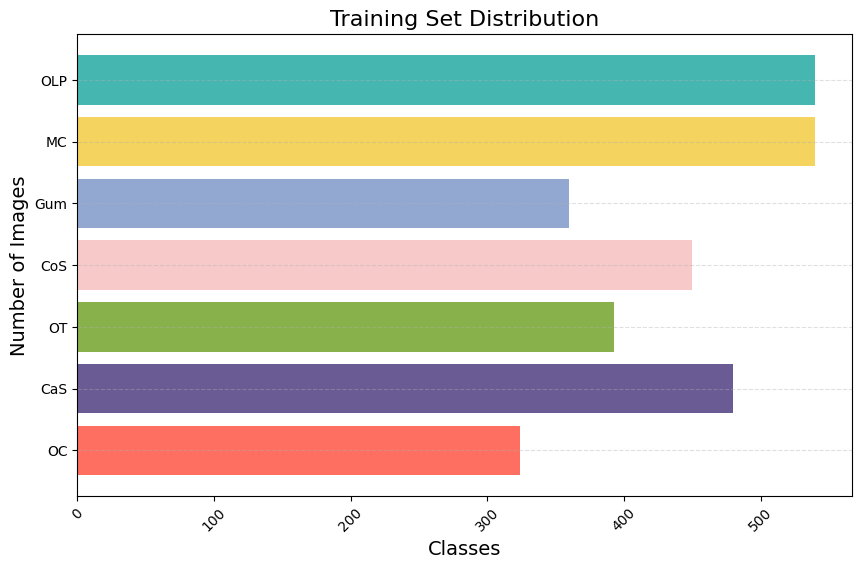

In [6]:
def plot_distribution(counts, title, colors):
    classes = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(10,6))
    plt.barh(classes, values, color=colors)
    plt.title(title, fontsize=16)
    plt.xlabel('Classes', fontsize=14)
    plt.ylabel('Number of Images', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()

colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1', '#F4D35E', '#45B7B0']

plot_distribution(train_counts, 'Training Set Distribution', colors)

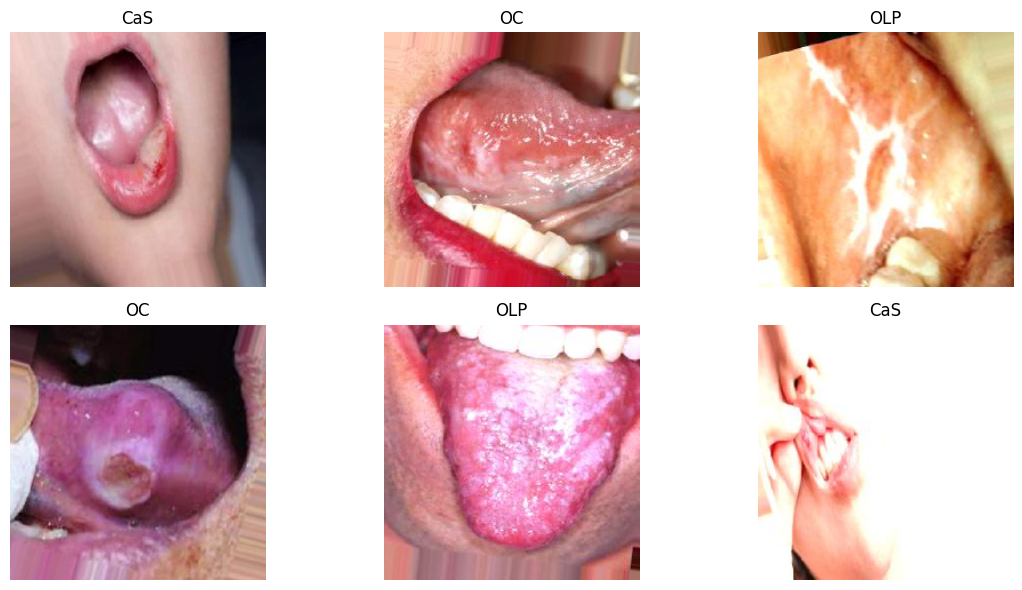

In [7]:
num_samples = 6
image_size = (224, 224)

classes = [c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))]

plt.figure(figsize=(12,6))

for i in range(num_samples):
    # Pick random class
    sample_class = random.choice(classes)
    sample_dir = os.path.join(train_dir, sample_class)

    # Pick random image
    sample_image = random.choice(os.listdir(sample_dir))
    sample_path = os.path.join(sample_dir, sample_image)

    img = load_img(sample_path, target_size=image_size)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis('off')

plt.tight_layout()
plt.show()



In [8]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


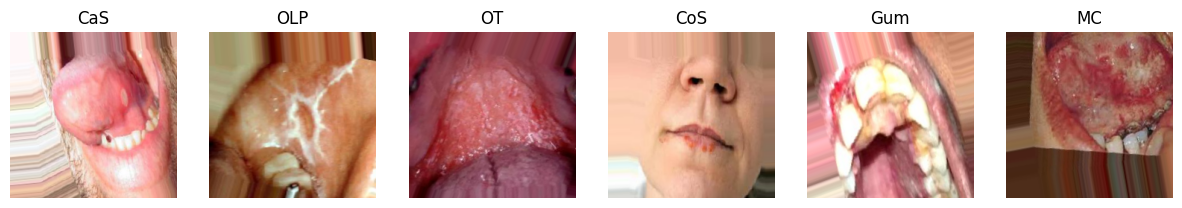

In [9]:

classes = [c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))]
selected_classes = random.sample(classes, 6)   # 6 different diseases

plt.figure(figsize=(15,3))

for i, cls in enumerate(selected_classes):
    img_name = random.choice(os.listdir(os.path.join(train_dir, cls)))
    img_path = os.path.join(train_dir, cls, img_name)

    img = load_img(img_path, target_size=image_size)
    x = img_to_array(img).astype('float32')

    augmented = train_datagen.random_transform(x)

    plt.subplot(1,6,i+1)
    plt.imshow(augmented.astype('uint8'))
    plt.axis('off')
    plt.title(cls)

plt.show()

In [10]:
train_labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.91875), 1: np.float64(0.98), 2: np.float64(1.225), 3: np.float64(0.8166666666666667), 4: np.float64(1.3611111111111112), 5: np.float64(0.8166666666666667), 6: np.float64(1.1221374045801527)}


In [11]:
pre_trained_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Make all the layers in the pre-trained model non-trainable
for layer in pre_trained_model.layers:
    layer.trainable = False
    

# Print the model summary
print(pre_trained_model.summary())

I0000 00:00:1775127163.229656      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775127163.235594      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [12]:
model = models.Sequential([
    pre_trained_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,859,079 (91.02 MB)

 Trainable params: 267,271 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [13]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',      
    patience=5,              
    restore_best_weights=True
)

In [15]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    class_weight=class_weights,  
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1775127174.860785     150 service.cc:152] XLA service 0x79898c013640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775127174.860831     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775127174.860837     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775127176.825126     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/97 ━━━━━━━━━━━━━━━━━━━━ 23:47 15s/step - accuracy: 0.1875 - loss: 3.1207

I0000 00:00:1775127182.513285     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


97/97 ━━━━━━━━━━━━━━━━━━━━ 75s 622ms/step - accuracy: 0.2205 - loss: 2.8829 - val_accuracy: 0.5126 - val_loss: 1.3511
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 399ms/step - accuracy: 0.3706 - loss: 2.0212 - val_accuracy: 0.6304 - val_loss: 1.0404
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 396ms/step - accuracy: 0.4465 - loss: 1.7548 - val_accuracy: 0.6858 - val_loss: 0.8987
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 389ms/step - accuracy: 0.5076 - loss: 1.4986 - val_accuracy: 0.7247 - val_loss: 0.7867
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 394ms/step - accuracy: 0.5384 - loss: 1.3931 - val_accuracy: 0.7383 - val_loss: 0.7142
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 389ms/step - accuracy: 0.5657 - loss: 1.2699 - val_accuracy: 0.7714 - val_loss: 0.6544
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 388ms/step - accuracy: 0.5829 - loss: 1.2293 - val_accuracy: 0.7889 - val_loss: 0.5988
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 388ms/step - accuracy: 0.6253 - loss: 1.0873 - val_accuracy: 0.812

In [16]:
# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f'Test accuracy: {test_acc:.4f}')


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.9822 - loss: 0.0759
Test accuracy: 0.9717


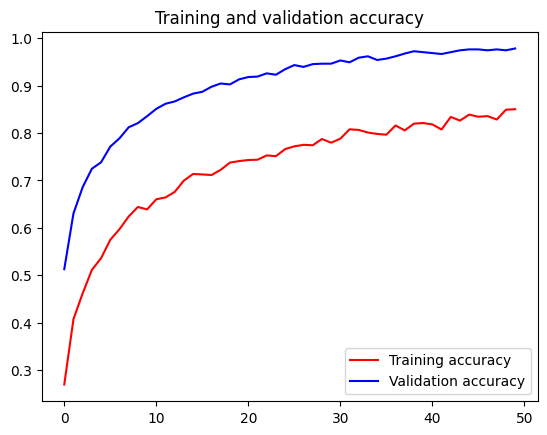

<Figure size 640x480 with 0 Axes>

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()


plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

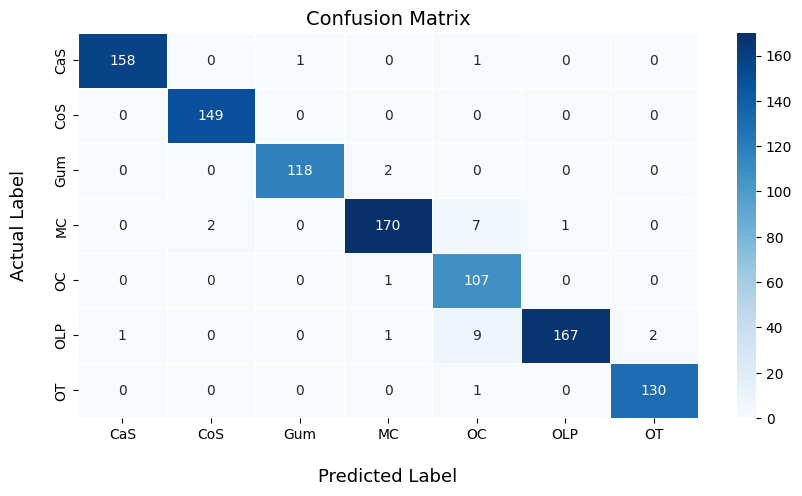

In [18]:
labels = list(test_generator.class_indices.keys())
num_classes = len(labels)

actual_labels = []
predicted_labels = []

for i in range(len(test_generator)):
    images, batch_labels = test_generator[i]
    batch_preds = model.predict(images)
    batch_preds = np.argmax(batch_preds, axis=1)

    batch_labels = np.argmax(batch_labels, axis=1)

    actual_labels.extend(batch_labels)
    predicted_labels.extend(batch_preds)

actual_labels = np.array(actual_labels, dtype=int)
predicted_labels = np.array(predicted_labels, dtype=int)

cm = confusion_matrix(actual_labels, predicted_labels)
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, linewidths=0.5)
plt.xlabel('\nPredicted Label', fontsize=13)
plt.ylabel('Actual Label\n', fontsize=13)
plt.title("Confusion Matrix", fontsize=14)
plt.show()

In [19]:
report = classification_report(actual_labels, predicted_labels, target_names=labels)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

         CaS       0.99      0.99      0.99       160
         CoS       0.99      1.00      0.99       149
         Gum       0.99      0.98      0.99       120
          MC       0.98      0.94      0.96       180
          OC       0.86      0.99      0.92       108
         OLP       0.99      0.93      0.96       180
          OT       0.98      0.99      0.99       131

    accuracy                           0.97      1028
   macro avg       0.97      0.98      0.97      1028
weighted avg       0.97      0.97      0.97      1028



In [22]:
model.save("teeth_model.h5")